# 🚗 Car Dheko – Model Development
**Pipeline:**
1. Load encoded data & split
2. Normalise features (MinMaxScaler)
3. Baseline cross-validation across 4 algorithms
4. Model comparison on held-out test set
5. Hyperparameter tuning (RandomizedSearchCV) on best model
6. Final evaluation & visualisations
7. Save artefacts (`model.pkl`, `scaler.pkl`)

---
## 1. Imports & Data Loading

In [1]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.4f}'.format)

# ── Load encoded data ────────────────────────────────────────────────────────
df = pd.read_excel('../Utility Files/encoded_car_data.xlsx')   # output from the pipeline notebook
print(f'Dataset shape: {df.shape}')
df.head(2)

Dataset shape: (7853, 16)


,Fuel type,Body type,Kilometers driven,transmission,ownerNo,model,modelYear,variantName,price,Registration Year,Insurance Validity,Mileage(kmpl),Engine(CC),Max Power(bhp),Torque(Nm),City
0,4,3,120000,1,3,135,2015,1616,"400,000.0000",2015,5,23.1000,998,67.0400,90.0000,0
1,4,7,32706,1,2,41,2018,279,"811,000.0000",2018,2,17.0000,1497,121.3100,150.0000,0


---
## 2. Feature / Target Split & Train-Test Split

In [2]:
X = df.drop(columns=['price'])   # features
y = df['price']                  # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train size : {X_train.shape[0]:,}')
print(f'Test size  : {X_test.shape[0]:,}')
print(f'Features   : {X_train.shape[1]}')

Train size : 6,282
Test size  : 1,571
Features   : 15


---
## 3. Normalise Numerical Features (MinMaxScaler)

In [5]:
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # apply same scale to test

# Persist scaler immediately so it can be reused in the Streamlit app
with open('../Utility Files/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('scaler.pkl saved ✔')

scaler.pkl saved ✔


---
## 4. Baseline Cross-Validation (5-fold, R²)

In [6]:
baseline_models = {
    'Linear Regression'          : LinearRegression(),
    'Decision Tree'              : DecisionTreeRegressor(random_state=42),
    'Random Forest'              : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'          : GradientBoostingRegressor(random_state=42),
}

cv_results = {}
for name, model in baseline_models.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = {'mean_r2': scores.mean(), 'std_r2': scores.std()}
    print(f'{name:<30}  CV R² = {scores.mean():.4f}  (± {scores.std():.4f})')

cv_df = pd.DataFrame(cv_results).T.sort_values('mean_r2', ascending=False)
cv_df

Linear Regression               CV R² = 0.7355  (± 0.0126)
Decision Tree                   CV R² = 0.8606  (± 0.0298)
Random Forest                   CV R² = 0.9219  (± 0.0124)
Gradient Boosting               CV R² = 0.8996  (± 0.0111)


,mean_r2,std_r2
Random Forest,0.9219,0.0124
Gradient Boosting,0.8996,0.0111
Decision Tree,0.8606,0.0298
Linear Regression,0.7355,0.0126


---
## 5. Model Comparison on Held-Out Test Set

In [7]:
# Train each baseline model on the full training set and evaluate on test
lr = LinearRegression().fit(X_train_sc, y_train)
dt = DecisionTreeRegressor(random_state=42).fit(X_train_sc, y_train)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train_sc, y_train)
gb = GradientBoostingRegressor(random_state=42).fit(X_train_sc, y_train)

model_list = [
    ('Linear Regression',           lr),
    ('Decision Tree Regressor',     dt),
    ('Random Forest Regressor',     rf),
    ('Gradient Boosting Regressor', gb),
]

rows = []
for name, m in model_list:
    preds = m.predict(X_test_sc)
    rows.append({
        'Model'   : name,
        'MAE'     : mean_absolute_error(y_test, preds),
        'RMSE'    : np.sqrt(mean_squared_error(y_test, preds)),
        'R² Score': r2_score(y_test, preds),
    })

comparison_df = pd.DataFrame(rows).sort_values('R² Score', ascending=False).reset_index(drop=True)
print('\nTest-set comparison:')
comparison_df


Test-set comparison:


,Model,MAE,RMSE,R² Score
0,Random Forest Regressor,"89,905.3365","167,211.8718",0.9416
1,Gradient Boosting Regressor,"114,597.0944","202,607.2350",0.9143
2,Decision Tree Regressor,"118,576.5759","228,176.3612",0.8913
3,Linear Regression,"223,370.8792","348,656.0306",0.7462


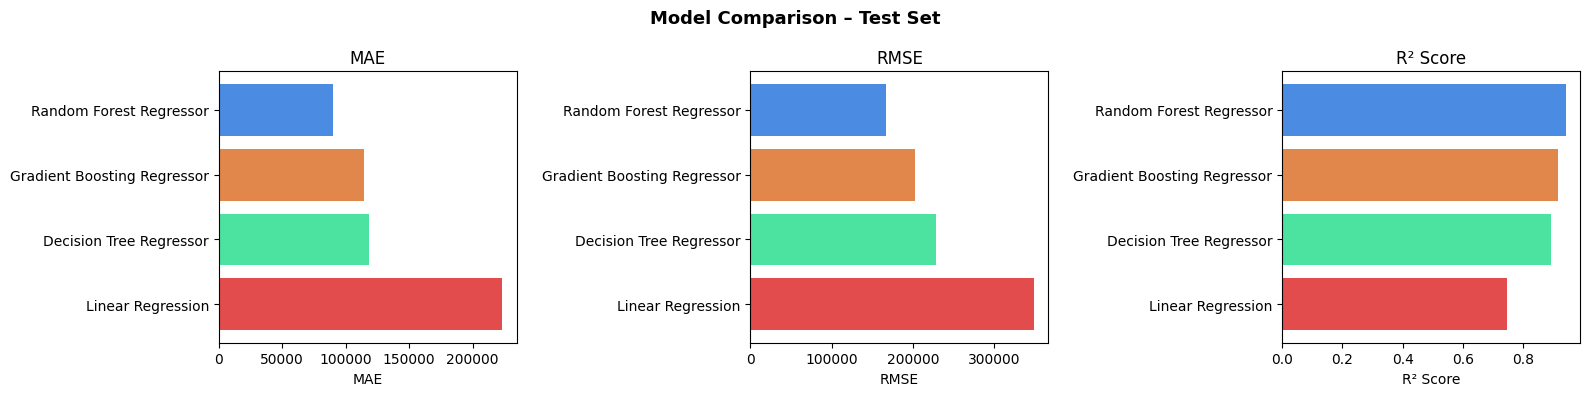

In [8]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics = ['MAE', 'RMSE', 'R² Score']
colours = ['#4C8BE2', '#E2874C', '#4CE2A0', '#E24C4C']

for ax, metric in zip(axes, metrics):
    ax.barh(comparison_df['Model'], comparison_df[metric], color=colours)
    ax.set_title(metric)
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle('Model Comparison – Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Random Forest** consistently achieves the highest R² and lowest error, so it is selected for hyperparameter tuning.

---
## 6. Hyperparameter Tuning – Random Forest (RandomizedSearchCV)

In [9]:
param_dist = {
    'n_estimators'      : [100, 200, 300, 400, 500],
    'max_depth'         : [None, 10, 20, 30, 40],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2', 0.5],
    'bootstrap'         : [True, False],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator  = rf_base,
    param_distributions = param_dist,
    n_iter     = 50,          # number of random combinations to try
    cv         = 5,           # 5-fold cross-validation
    scoring    = 'r2',
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1,
    refit      = True,        # refit best estimator on full training data
)

random_search.fit(X_train_sc, y_train)

print('\n── Best Parameters ──')
for k, v in random_search.best_params_.items():
    print(f'  {k:<25}: {v}')
print(f'\nBest CV R²: {random_search.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

── Best Parameters ──
  n_estimators             : 200
  min_samples_split        : 2
  min_samples_leaf         : 1
  max_features             : 0.5
  max_depth                : 20
  bootstrap                : False

Best CV R²: 0.9292


---
## 7. Final Model Evaluation

In [10]:
best_rf = random_search.best_estimator_
y_pred  = best_rf.predict(X_test_sc)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('──────────────────────────────────────')
print(f'  MAE   : ₹ {mae:>15,.2f}')
print(f'  RMSE  : ₹ {rmse:>15,.2f}')
print(f'  R²    :   {r2:>15.4f}')
print(f'  MAPE  :   {mape:>14.2f} %')
print('──────────────────────────────────────')

# Baseline vs tuned comparison
baseline_rf_r2 = r2_score(y_test, rf.predict(X_test_sc))
print(f'\nBaseline RF R²  : {baseline_rf_r2:.4f}')
print(f'Tuned    RF R²  : {r2:.4f}   (+{r2 - baseline_rf_r2:.4f})')

──────────────────────────────────────
  MAE   : ₹       86,031.87
  RMSE  : ₹      154,109.39
  R²    :            0.9504
  MAPE  :          1621.74 %
──────────────────────────────────────

Baseline RF R²  : 0.9416
Tuned    RF R²  : 0.9504   (+0.0088)


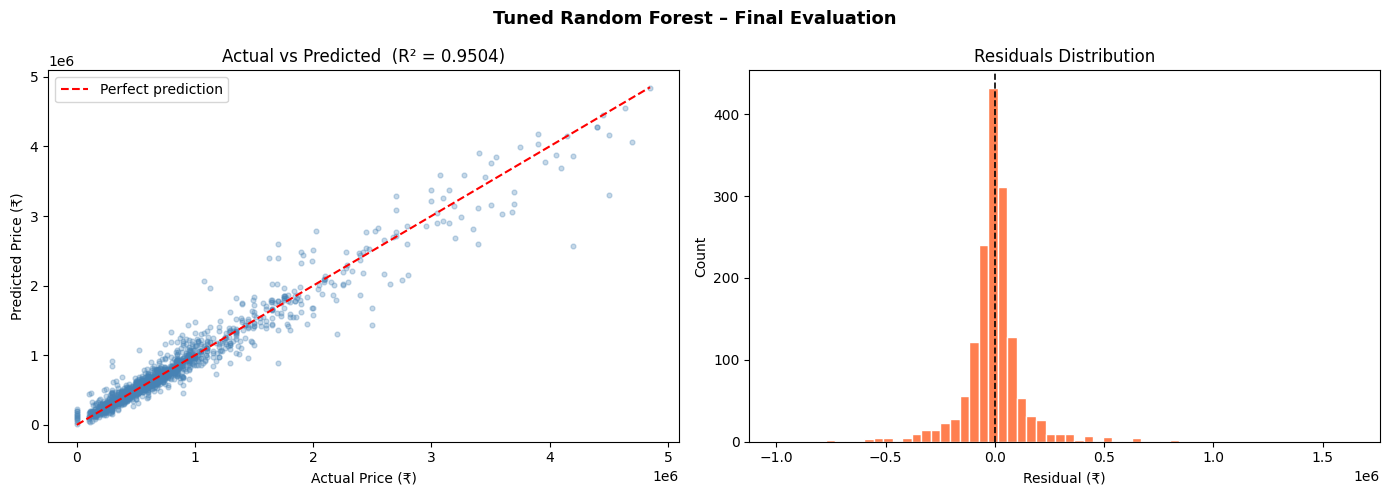

In [11]:
# ── Actual vs Predicted ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.3, s=12, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (₹)')
ax.set_ylabel('Predicted Price (₹)')
ax.set_title(f'Actual vs Predicted  (R² = {r2:.4f})')
ax.legend()

# Residuals distribution
ax = axes[1]
residuals = y_test - y_pred
ax.hist(residuals, bins=60, color='coral', edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Residual (₹)')
ax.set_ylabel('Count')
ax.set_title('Residuals Distribution')

plt.suptitle('Tuned Random Forest – Final Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

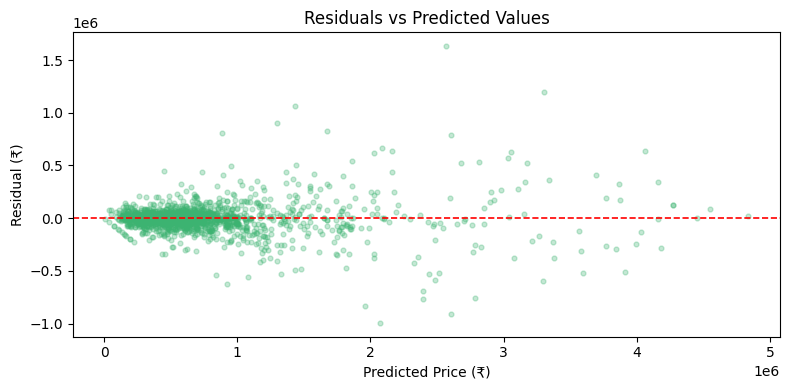

In [12]:
# ── Residuals vs Predicted (heteroscedasticity check) ─────────────────────────
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.3, s=12, color='mediumseagreen')
plt.axhline(0, color='red', linewidth=1.2, linestyle='--')
plt.xlabel('Predicted Price (₹)')
plt.ylabel('Residual (₹)')
plt.title('Residuals vs Predicted Values')
plt.tight_layout()
plt.show()

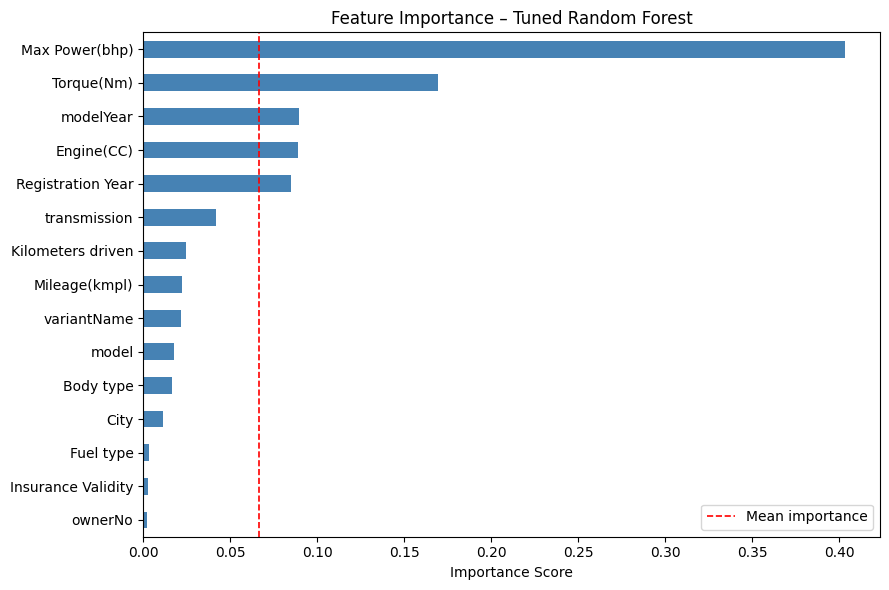


Top 5 features:
Max Power(bhp)      0.4032
Torque(Nm)          0.1695
modelYear           0.0895
Engine(CC)          0.0890
Registration Year   0.0849
dtype: float64


In [13]:
# ── Feature importance (tuned model) ─────────────────────────────────────────
feat_imp = (
    pd.Series(best_rf.feature_importances_, index=X.columns)
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.axvline(feat_imp.mean(), color='red', linestyle='--', linewidth=1.2, label='Mean importance')
plt.legend()
plt.title('Feature Importance – Tuned Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(feat_imp.sort_values(ascending=False).head())

---
## 8. Save Model Artefact

In [14]:
with open('../Utility Files/model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
print('model.pkl saved  ✔')
print('scaler.pkl saved ✔  (saved in section 3)')

# Quick sanity-check: reload and re-predict one sample
with open('../Utility Files/model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

sample = X_test_sc[:1]
check  = loaded_model.predict(sample)[0]
actual = y_test.iloc[0]
print(f'\nSanity check – predicted: ₹ {check:,.2f}   actual: ₹ {actual:,.2f}')

model.pkl saved  ✔
scaler.pkl saved ✔  (saved in section 3)

Sanity check – predicted: ₹ 1,150,795.83   actual: ₹ 1,500,000.00


---
## Summary

| Artefact | File | Purpose |
|---|---|---|
| Trained model | `model.pkl` | RandomForest with tuned hyperparameters |
| Feature scaler | `scaler.pkl` | MinMaxScaler fitted on training data |

Both files are consumed by `Price_Prediction.py` (Streamlit app).